In [1]:
# Phase 3 — Anomaly Detection
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('cleaned_weather_data.csv')
df['last_updated'] = pd.to_datetime(df['last_updated'])
plt.style.use('seaborn-v0_8')

# Select features for anomaly detection
features = ['temperature_celsius', 'humidity', 'wind_mph', 
            'pressure_mb', 'precip_mm', 'uv_index']

X = df[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Isolation Forest — detects anomalies automatically
iso_forest = IsolationForest(contamination=0.05, random_state=42)
df['anomaly'] = iso_forest.fit_predict(X_scaled)
df['anomaly_label'] = df['anomaly'].map({1: 'Normal', -1: 'Anomaly'})

anomaly_count = (df['anomaly'] == -1).sum()
print(f"Total anomalies detected: {anomaly_count}")
print(f"Anomaly percentage: {anomaly_count/len(df)*100:.1f}%")

Total anomalies detected: 6816
Anomaly percentage: 5.0%


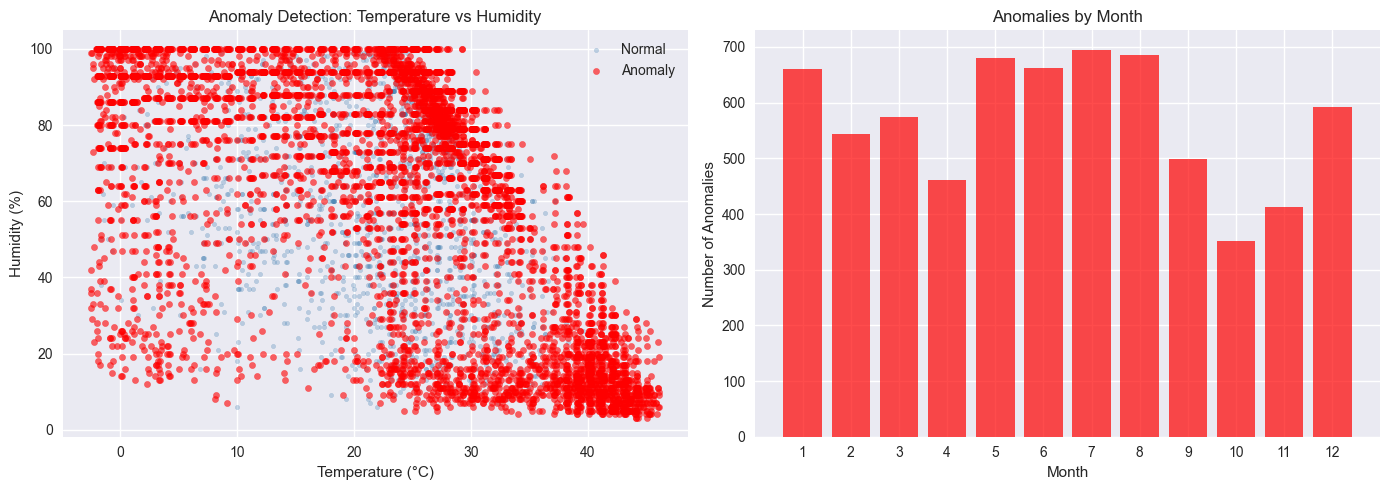

✅ Anomaly plot saved!


In [2]:
# Visualize anomalies on temperature vs humidity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Anomalies on scatter plot
normal = df[df['anomaly_label'] == 'Normal'].sample(3000, random_state=42)
anomalies = df[df['anomaly_label'] == 'Anomaly']

axes[0].scatter(normal['temperature_celsius'], normal['humidity'], 
                c='steelblue', alpha=0.3, s=10, label='Normal')
axes[0].scatter(anomalies['temperature_celsius'], anomalies['humidity'], 
                c='red', alpha=0.6, s=20, label='Anomaly')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Humidity (%)')
axes[0].set_title('Anomaly Detection: Temperature vs Humidity')
axes[0].legend()

# Plot 2: Anomalies over time
monthly_anomalies = df[df['anomaly_label'] == 'Anomaly'].groupby('month').size()
axes[1].bar(monthly_anomalies.index, monthly_anomalies.values, color='red', alpha=0.7)
axes[1].set_title('Anomalies by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of Anomalies')
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.savefig('plot_anomalies.png', dpi=150)
plt.show()
print("✅ Anomaly plot saved!")